# 01 — Carga y limpieza — Black Basta

Parsea `blackbasta_chats.json`, limpia el dataset y genera  
`data/processed/blackbasta_unified.parquet`.

## 0. Setup

In [1]:
# sys nos permite modificar la lista de rutas donde Python busca módulos.
# Lo necesitamos para que Python encuentre nuestro código personalizado en 'src/'.
import sys

# Path es la herramienta de Python para trabajar con rutas de archivos
# de forma segura y compatible con todos los sistemas operativos.
from pathlib import Path

# Añadimos la carpeta 'src' al inicio de la lista de búsqueda de módulos.
# resolve() convierte la ruta relativa 'src' a una ruta absoluta completa.
# str() la convierte a texto, que es lo que espera sys.path.insert.
sys.path.insert(0, str(Path('src').resolve()))

# pandas es la librería principal para trabajar con tablas de datos (DataFrames).
# La convención es importarla como 'pd' para escribir menos al usarla.
import pandas as pd

# matplotlib permite crear gráficas. pyplot es el submódulo con las funciones
# de dibujo habituales (plt.plot, plt.show, plt.subplots, etc.).
import matplotlib.pyplot as plt

# Importamos nuestra función de carga personalizada desde src/loaders.py.
# Esta función sabe leer el formato especial del fichero de Black Basta.
from loaders import load_blackbasta

# Ruta al fichero de datos crudos (sin procesar) de los chats de Black Basta.
# Adapta esta ruta a donde tengas el fichero de chats de Black Basta.
# Convención del repo: pon los datos brutos en BlackBasta/data_bruto/
RAW_FILE      = Path('data_bruto/blackbasta_chats.json')

# Ruta a la carpeta donde guardaremos los datos ya procesados y limpios.
# '..' significa "subir un nivel" desde la carpeta actual del notebook.
PROCESSED_DIR = Path('../data_Vruto/BlackBasta')

# mkdir crea la carpeta si no existe.
# parents=True crea también las carpetas intermedias si faltan ('data/' en este caso).
# exist_ok=True evita un error si la carpeta ya existía.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Comprobamos que el fichero de datos crudos existe antes de continuar.
# Si no existe, el mensaje de error nos indica exactamente qué ruta buscar.
assert RAW_FILE.exists(), f'No se encuentra {RAW_FILE}'
print('Setup OK')

Setup OK


## 1. Carga

In [2]:
print('Cargando blackbasta_chats.json...')

# Llamamos a nuestra función de carga: parsea el fichero crudo y devuelve
# un DataFrame limpio con las columnas timestamp, username, channel, message, source.
df = load_blackbasta(RAW_FILE)

# Mostramos cuántos mensajes se cargaron y el rango de fechas para verificar
# que todo fue bien. Las f-strings con {:,} añaden separadores de miles.
print(f'  → {len(df):,} mensajes | rango: {df.timestamp.min()} → {df.timestamp.max()}')

# display() muestra las primeras 3 filas como tabla HTML en Jupyter,
# lo que es mucho más cómodo de leer que un print normal.
display(df.head(3))

Cargando blackbasta_chats.json...


  → 195,407 mensajes | rango: 2023-09-18 13:35:07+00:00 → 2024-09-28 17:11:23+00:00


,timestamp,username,channel,message,source
0,2023-09-18 13:35:07+00:00,usernamenn,VdvDXHFZwWDpIAtpCj,BAZA,blackbasta
1,2023-09-18 13:50:31+00:00,usernamess,uJZKZVgGmmSiNvobZH,!!!,blackbasta
2,2023-09-18 17:43:18+00:00,usernameyy,FtoGkSqUPiGjGNKkOl,"cpu 2core 2.4 ghz, 4 gb ram, 100 gb space x2",blackbasta


## 2. Limpieza

In [3]:
# Guardamos cuántas filas teníamos antes de limpiar, para luego poder
# mostrar cuántas se eliminaron durante el proceso.
n_before = len(df)

# PASO 1: Eliminar mensajes vacíos o que solo contienen espacios en blanco.
# strip() elimina espacios y saltos de línea del inicio y final del texto.
# str.len() calcula la longitud del texto ya limpio.
# > 0 filtra y se queda solo con los mensajes que tienen al menos un carácter real.
df = df[df['message'].str.strip().str.len() > 0]

# PASO 2: Eliminar mensajes duplicados exactos.
# Un duplicado exacto es un mensaje del mismo usuario, en el mismo momento y con
# el mismo texto. drop_duplicates() elimina todas las filas repetidas
# excepto la primera vez que aparecen.
df = df.drop_duplicates(subset=['timestamp', 'username', 'message'])

# PASO 3: Eliminar filas con timestamps inválidos (NaT = "Not a Time").
# dropna() elimina filas donde la columna indicada tiene un valor nulo.
# Estos timestamps inválidos surgen cuando el texto de la fecha no pudo parsearse.
df = df.dropna(subset=['timestamp'])

# PASO 4: Normalizar nombres de usuario.
# str.strip() elimina espacios sobrantes.
# str.lower() convierte a minúsculas para que 'UserName' y 'username' sean lo mismo.
# Así evitamos contar al mismo usuario como dos actores distintos por diferencias
# de mayúsculas/minúsculas.
df['username'] = df['username'].str.strip().str.lower()

# Normalizamos también el nombre del canal, solo eliminando espacios.
df['channel']  = df['channel'].str.strip()

# PASO 5: Ordenar los mensajes cronológicamente (del más antiguo al más reciente).
# sort_values('timestamp') reordena todas las filas por fecha y hora.
# reset_index(drop=True) reasigna números de fila consecutivos (0, 1, 2, ...)
# después del reordenamiento. drop=True evita que el índice antiguo se guarde
# como una columna extra.
df = df.sort_values('timestamp').reset_index(drop=True)

# Mostramos cuántas filas se eliminaron y cuántas quedaron después de la limpieza.
print(f'Filas eliminadas : {n_before - len(df):,}')
print(f'Mensajes limpios : {len(df):,}')

Filas eliminadas : 10
Mensajes limpios : 195,397


## 3. Detección de idioma

In [4]:
# langdetect es una librería que detecta automáticamente el idioma de un texto.
# Funciona analizando patrones estadísticos del texto (como qué letras y palabras
# son más frecuentes en cada idioma). detect() es la función principal;
# LangDetectException es el error que lanza cuando no puede determinar el idioma.
from langdetect import detect, LangDetectException

# tqdm es una librería que muestra barras de progreso.
# Cuando procesamos miles de mensajes, la barra nos indica cuánto falta para terminar.
# tqdm.auto elige automáticamente entre la versión de terminal y la de notebook.
from tqdm.auto import tqdm


def safe_detect(text):
    """
    Detecta el idioma de un texto de forma segura, sin lanzar excepciones.

    Usamos un envoltorio (wrapper) sobre detect() porque algunos textos
    muy cortos, con números o con caracteres raros no pueden detectarse,
    y en esos casos la librería lanza una excepción en lugar de devolver None.

    Parámetros:
        text (str): El texto del mensaje a analizar.

    Devuelve:
        str: Código de idioma ISO 639-1 (por ejemplo, 'ru' para ruso,
             'en' para inglés). Si no puede determinarse, devuelve 'und'
             (undetermined = indeterminado).
    """
    try:
        # Limitamos el texto a los primeros 200 caracteres para ser más rápidos.
        # Para detectar el idioma no hace falta leer el mensaje completo.
        # str(text) garantiza que aunque text sea None u otro tipo, no falle.
        return detect(str(text)[:200])
    except LangDetectException:
        # Si el idioma no puede determinarse (texto demasiado corto, solo números,
        # solo emojis, etc.), devolvemos 'und' como código especial.
        return 'und'


# tqdm.pandas() "envuelve" la función apply() de pandas para mostrar progreso.
# desc= es el texto que aparece junto a la barra de progreso.
tqdm.pandas(desc='Detectando idioma')

# Aplicamos safe_detect a cada mensaje de la columna 'message'.
# progress_apply() es como apply() pero con barra de progreso (gracias a tqdm).
# El resultado es una nueva columna 'lang' con el código de idioma de cada mensaje.
# Este proceso tarda varios minutos porque analiza casi 200.000 mensajes uno a uno.
df['lang'] = df['message'].progress_apply(safe_detect)

# Mostramos los 10 idiomas más comunes en el dataset.
# value_counts() cuenta cuántos mensajes hay de cada idioma y los ordena.
print('\nDistribución de idiomas:')
print(df.lang.value_counts().head(10).to_string())

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Detectando idioma:   0%|          | 0/195397 [00:00<?, ?it/s]

Detectando idioma:   0%|          | 2/195397 [00:00<3:40:18, 14.78it/s]

Detectando idioma:   0%|          | 43/195397 [00:00<15:21, 212.07it/s]

Detectando idioma:   0%|          | 119/195397 [00:00<07:24, 439.06it/s]

...

Detectando idioma: 100%|█████████▉| 195253/195397 [04:41<00:00, 692.44it/s]

Detectando idioma: 100%|█████████▉| 195325/195397 [04:41<00:00, 693.13it/s]

Detectando idioma: 100%|█████████▉| 195396/195397 [04:41<00:00, 664.42it/s]

Detectando idioma: 100%|██████████| 195397/195397 [04:41<00:00, 694.29it/s]


Distribución de idiomas:
lang
ru     106728
mk      17069
bg      16723
und     13492
en      12362
uk       6860
tl       2369
ca       2247
et       1936
cy       1691


## 4. Estadísticas finales

In [5]:
# Imprimimos un resumen completo del dataset después de la limpieza
# para tener una visión global antes de guardarlo.
print('=== DATASET BLACK BASTA ===')

# Número total de mensajes tras la limpieza.
print(f'  Mensajes totales : {len(df):,}')

# nunique() cuenta los valores distintos en cada columna.
print(f'  Actores únicos   : {df.username.nunique()}')
print(f'  Canales únicos   : {df.channel.nunique()}')

# .date() extrae solo la parte de fecha (año-mes-día) de un timestamp completo.
print(f'  Rango temporal   : {df.timestamp.min().date()} → {df.timestamp.max().date()}')
print()

# Mostramos los 20 usuarios más activos.
# groupby + size + sort_values + head: agrupa, cuenta, ordena y se queda con los 20 primeros.
# to_string() evita que pandas trunque la lista con "...".
print('Top 20 actores:')
print(df.groupby('username').size().sort_values(ascending=False).head(20).to_string())

=== DATASET BLACK BASTA ===
  Mensajes totales : 195,397
  Actores únicos   : 49
  Canales únicos   : 79
  Rango temporal   : 2023-09-18 → 2024-09-28

Top 20 actores:
username
usernamegg        83066
lapa              26258
w                 13439
usernamenn         8509
usernameyy         7172
n3auxaxl           6386
usernameugway      6075
usernamess         5504
nickolas           3669
cameron777         3641
muaddib6           2454
ssd                2280
burito             2169
usernameww         1694
cob_crypt_ward     1678
usernamevv         1641
lincoln            1640
usernamemm         1609
usernamezz         1534
usernamett         1516


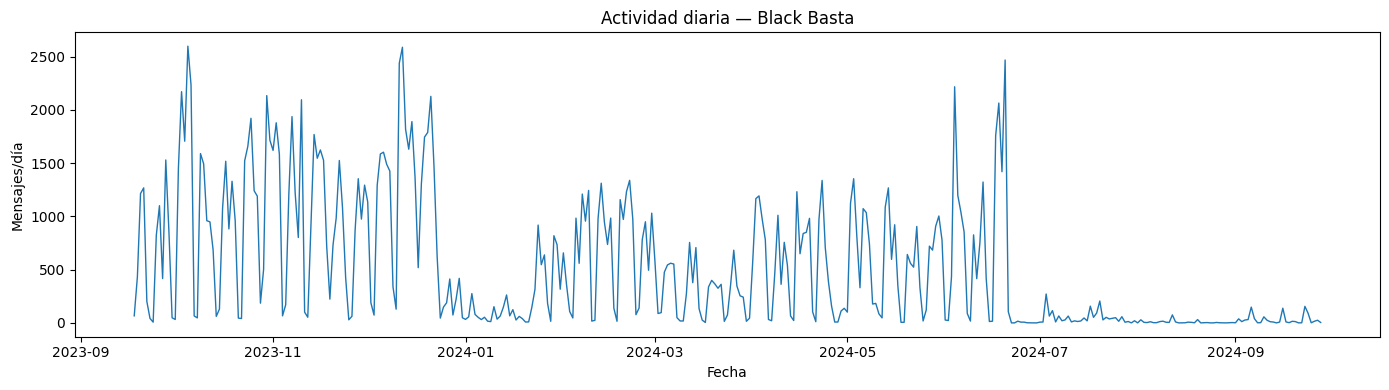

In [6]:
# Calculamos la actividad diaria del grupo para visualizar su comportamiento en el tiempo.
# set_index('timestamp') hace de la columna de fechas el índice del DataFrame.
# resample('D') agrupa las filas por día completo (D = Day).
# .size() cuenta cuántas filas (mensajes) hay en cada día.
daily = df.set_index('timestamp').resample('D').size()

# Creamos la figura del gráfico.
# 14 de ancho x 4 de alto es un formato apaisado, ideal para series temporales.
fig, ax = plt.subplots(figsize=(14, 4))

# Dibujamos la línea de actividad: eje X = fechas, eje Y = número de mensajes ese día.
# linewidth=1 hace la línea fina para que los picos sean bien visibles.
ax.plot(daily.index, daily.values, linewidth=1)

# Añadimos etiquetas descriptivas al gráfico.
ax.set_title('Actividad diaria — Black Basta')
ax.set_xlabel('Fecha')
ax.set_ylabel('Mensajes/día')

# tight_layout() ajusta los márgenes automáticamente para evitar que las etiquetas
# queden cortadas por los bordes de la imagen.
plt.tight_layout()
plt.show()

## 5. Guardar

In [7]:
# Definimos la ruta completa del fichero de salida.
# El operador / entre objetos Path concatena las rutas de forma segura.
out_path = PROCESSED_DIR / 'blackbasta_unified.parquet'

# Guardamos el DataFrame en formato Parquet.
# Parquet es un formato de almacenamiento en columnas, mucho más eficiente que CSV:
# ocupa menos espacio y se carga mucho más rápido, especialmente con datos grandes.
# index=False evita que el número de fila (0, 1, 2, ...) se guarde como columna extra.
df.to_parquet(out_path, index=False)

# Confirmamos que el guardado fue exitoso mostrando la ruta y el tamaño del fichero.
print(f'Guardado: {out_path}')

# stat().st_size devuelve el tamaño en bytes; dividir entre 1024**2 convierte a MB.
print(f'Tamaño:   {out_path.stat().st_size / 1024**2:.1f} MB')

# Mostramos las columnas del DataFrame guardado para referencia futura.
print(f'Columnas: {list(df.columns)}')

# dtypes muestra el tipo de dato de cada columna (texto, número, fecha, etc.).
# to_string() evita que la salida se trunque.
print(f'Tipos:\n{df.dtypes.to_string()}')

Guardado: data/processed/blackbasta_unified.parquet
Tamaño:   9.2 MB
Columnas: ['timestamp', 'username', 'channel', 'message', 'source', 'lang']
Tipos:
timestamp    datetime64[us, UTC]
username                     str
channel                      str
message                      str
source                       str
lang                         str
